# Leaf vs Non-Leaf Classification Model

Binary classifier to detect whether an image contains a **plant leaf** or **other** (non-leaf). Used as a gatekeeper before running the disease model so out-of-distribution inputs are rejected.
Classes: **Leaf**, **Other**.
Uses ResNet18 and stratified train/val split. Model is saved to `export/`.

**Importing libraries**

Import PyTorch, torchvision, sklearn, PIL, and set the device (GPU if available).

In [43]:
import json
import random
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
from PIL import Image
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, Dataset
from torchvision import models, transforms

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


**Config and paths**

Set project root (parent of `notebook/`), data path `data/leaf_vs_non-leaf`, export dir `export/`, image size, batch size, epochs, and seed.

In [44]:
# Project root: cwd if it contains "data", else parent (e.g. when run from notebook/)
_cwd = Path.cwd()
PROJECT_ROOT = _cwd if (_cwd / "data").exists() else _cwd.parent
DATA_ROOT = PROJECT_ROOT / "data" / "leaf_vs_non-leaf"
EXPORT_DIR = PROJECT_ROOT / "export"

IMG_SIZE = 224
BATCH_SIZE = 64
EPOCHS = 15
LR = 1e-3
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print("DATA_ROOT:", DATA_ROOT)
print("EXPORT_DIR:", EXPORT_DIR)

DATA_ROOT: e:\fyp\py\data\leaf_vs_non-leaf
EXPORT_DIR: e:\fyp\py\export


**Collecting image paths and labels**

Scan `leaf` and `other` folders and build lists of file paths and integer labels. Class names: **Leaf** (0), **Other** (1).

In [45]:
CLASS_NAMES = ["Leaf", "Other"]
extensions = (".jpg", ".jpeg", ".png", ".JPG", ".JPEG", ".PNG", ".webp", ".WEBP")

paths = []
labels = []
for label, name in enumerate(CLASS_NAMES):
    folder = DATA_ROOT / name.lower()
    if not folder.is_dir():
        continue
    for f in folder.iterdir():
        if f.is_file() and f.suffix.lower() in (e.lower() for e in extensions):
            paths.append(str(f))
            labels.append(label)

print("Total images:", len(paths))
print("Per class:", [sum(1 for l in labels if l == i) for i in range(len(CLASS_NAMES))])

Total images: 2545
Per class: [1853, 692]


**Stratified train/validation split**

Split paths and labels 80% train / 20% val, keeping class proportions.

In [46]:
train_paths, val_paths, train_labels, val_labels = train_test_split(
    paths, labels, test_size=0.2, stratify=labels, random_state=SEED
)
print("Train:", len(train_paths), "Val:", len(val_paths))

Train: 2036 Val: 509


**Transforms**

Train: resize, horizontal/vertical flip, color jitter, ImageNet normalization. Val: resize and ImageNet normalization.

In [47]:
train_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])
val_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

In [48]:
class LeafVsOtherDataset(Dataset):
    def __init__(self, paths, labels, transform=None):
        self.paths = paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, i):
        img = Image.open(self.paths[i]).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img, self.labels[i]

In [49]:
train_ds = LeafVsOtherDataset(train_paths, train_labels, transform=train_tf)
val_ds = LeafVsOtherDataset(val_paths, val_labels, transform=val_tf)

train_loader = DataLoader(
    train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0, pin_memory=True
)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
print("DataLoaders ready.")

DataLoaders ready.


**Model**

ResNet18 with 2 output classes (Leaf, Other). Replace the final fully connected layer.

**Training setup**

Loss (cross-entropy), optimizer (Adam), and one-epoch training function.

In [50]:
num_classes = len(CLASS_NAMES)
model = models.resnet18(weights=None)
model.fc = nn.Linear(model.fc.in_features, num_classes)
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR)

def train_one_epoch(loader):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    for images, targets in loader:
        images, targets = images.to(device), targets.to(device)
        optimizer.zero_grad()
        logits = model(images)
        loss = criterion(logits, targets)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        _, pred = logits.max(1)
        total += targets.size(0)
        correct += pred.eq(targets).sum().item()
    return running_loss / len(loader), correct / total

In [51]:
num_classes = len(CLASS_NAMES)
model = models.resnet18(weights=None)
model.fc = nn.Linear(model.fc.in_features, num_classes)
model = model.to(device)
print("ResNet18, num_classes =", num_classes)

ResNet18, num_classes = 2


**Validation function**

Evaluate on validation loader: loss and accuracy.

**Training loop**

Run training for `EPOCHS`; print train/val loss and accuracy each epoch. Track best val accuracy and save best model state.

In [52]:
def validate(loader):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for images, targets in loader:
            images, targets = images.to(device), targets.to(device)
            logits = model(images)
            loss = criterion(logits, targets)
            running_loss += loss.item()
            _, pred = logits.max(1)
            total += targets.size(0)
            correct += pred.eq(targets).sum().item()
    return running_loss / len(loader), correct / total

best_val_acc = 0.0
best_state = None

for epoch in range(1, EPOCHS + 1):
    train_loss, train_acc = train_one_epoch(train_loader)
    val_loss, val_acc = validate(val_loader)
    print(f"Epoch {epoch}/{EPOCHS}  Train loss: {train_loss:.4f}  Train acc: {train_acc:.4f}  Val loss: {val_loss:.4f}  Val acc: {val_acc:.4f}")
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}

e:\fyp\py\.env\lib\site-packages\PIL\Image.py:1054: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Epoch 1/10  Train loss: 0.7635  Train acc: 0.7146  Val loss: 0.7876  Val acc: 0.7269
Epoch 2/10  Train loss: 0.7579  Train acc: 0.7102  Val loss: 0.8117  Val acc: 0.7269
Epoch 3/10  Train loss: 0.7688  Train acc: 0.7161  Val loss: 0.7957  Val acc: 0.7250
Epoch 4/10  Train loss: 0.7623  Train acc: 0.7166  Val loss: 0.7976  Val acc: 0.7250
Epoch 5/10  Train loss: 0.7661  Train acc: 0.7151  Val loss: 0.7933  Val acc: 0.7269
Epoch 6/10  Train loss: 0.7664  Train acc: 0.7171  Val loss: 0.8103  Val acc: 0.7289
Epoch 7/10  Train loss: 0.7599  Train acc: 0.7161  Val loss: 0.7955  Val acc: 0.7269
Epoch 8/10  Train loss: 0.7559  Train acc: 0.7102  Val loss: 0.8108  Val acc: 0.7269
Epoch 9/10  Train loss: 0.7579  Train acc: 0.7132  Val loss: 0.8011  Val acc: 0.7250
Epoch 10/10  Train loss: 0.7574  Train acc: 0.7122  Val loss: 0.7984  Val acc: 0.7269


**Load best model state**

Restore the model weights that achieved the highest validation accuracy.

In [53]:
def validate(loader):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for images, targets in loader:
            images, targets = images.to(device), targets.to(device)
            logits = model(images)
            loss = criterion(logits, targets)
            running_loss += loss.item()
            _, pred = logits.max(1)
            total += targets.size(0)
            correct += pred.eq(targets).sum().item()
    return running_loss / len(loader), correct / total

In [54]:
if best_state is not None:
    model.load_state_dict(best_state)
    print("Loaded best model. Best val acc:", best_val_acc)

Loaded best model. Best val acc: 0.7288801571709234


In [55]:
model.eval()
all_preds = []
all_labels = []
with torch.no_grad():
    for images, targets in val_loader:
        images = images.to(device)
        logits = model(images)
        _, pred = logits.max(1)
        all_preds.extend(pred.cpu().numpy().tolist())
        all_labels.extend(targets.numpy().tolist())

report_dict = classification_report(all_labels, all_preds, target_names=CLASS_NAMES, output_dict=True)
cm = confusion_matrix(all_labels, all_preds)

accuracy = report_dict["accuracy"]
macro_p = report_dict["macro avg"]["precision"]
macro_r = report_dict["macro avg"]["recall"]
macro_f1 = report_dict["macro avg"]["f1-score"]
print("Accuracy:", round(accuracy, 4))
print("Macro avg — Precision:", round(macro_p, 4), " Recall:", round(macro_r, 4), " F1:", round(macro_f1, 4))
print()
print(classification_report(all_labels, all_preds, target_names=CLASS_NAMES))
print("Confusion matrix:")
print(cm)

Accuracy: 0.7289
Macro avg — Precision: 0.3644  Recall: 0.5  F1: 0.4216

              precision    recall  f1-score   support

        Leaf       0.73      1.00      0.84       371
       Other       0.00      0.00      0.00       138

    accuracy                           0.73       509
   macro avg       0.36      0.50      0.42       509
weighted avg       0.53      0.73      0.61       509

Confusion matrix:
[[371   0]
 [138   0]]


e:\fyp\py\.env\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
e:\fyp\py\.env\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
e:\fyp\py\.env\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
e:\fyp\py\.env\lib\site-packages\sklearn\metrics\_classifi

**Bar graph: precision, recall, F1-score per class**

Plot precision, recall, and F1 for each class (Leaf, Other) as a grouped bar chart.

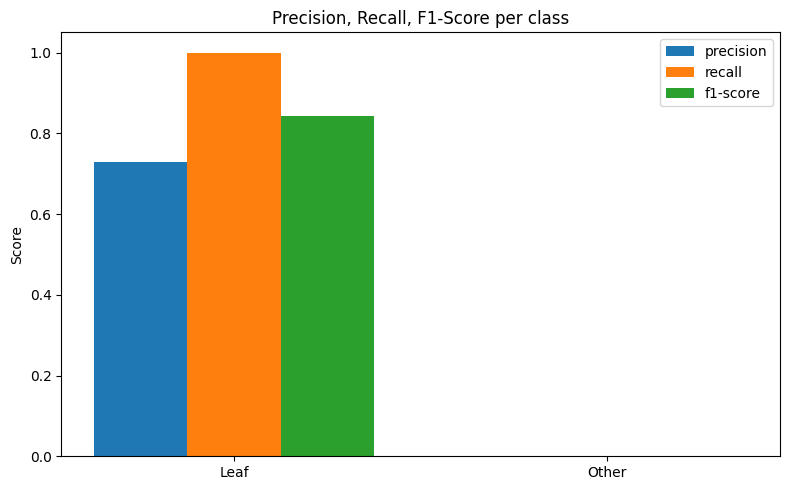

In [56]:
metrics = ["precision", "recall", "f1-score"]
x = np.arange(len(CLASS_NAMES))
width = 0.25

fig, ax = plt.subplots(figsize=(8, 5))
for i, m in enumerate(metrics):
    vals = [report_dict[c][m] for c in CLASS_NAMES]
    offset = width * (i - 1)
    ax.bar(x + offset, vals, width, label=m)

ax.set_xticks(x)
ax.set_xticklabels(CLASS_NAMES)
ax.set_ylabel("Score")
ax.set_title("Precision, Recall, F1-Score per class")
ax.legend()
ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.show()

**Confusion matrix heatmap**

Visualize the confusion matrix with class names on both axes.

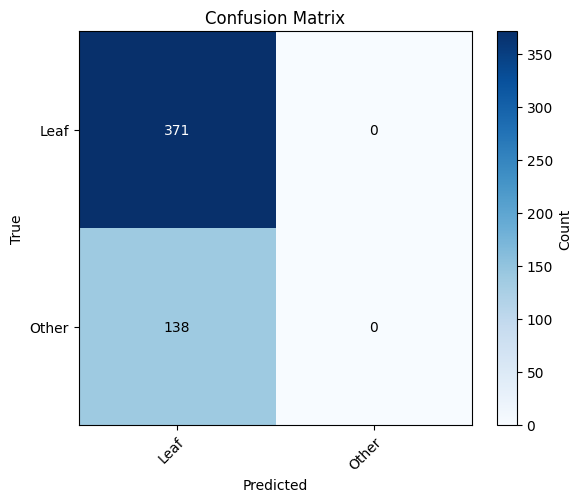

In [57]:
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks(np.arange(len(CLASS_NAMES)))
ax.set_yticks(np.arange(len(CLASS_NAMES)))
ax.set_xticklabels(CLASS_NAMES)
ax.set_yticklabels(CLASS_NAMES)
plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")
for i in range(len(CLASS_NAMES)):
    for j in range(len(CLASS_NAMES)):
        ax.text(j, i, cm[i, j], ha="center", va="center", color="black" if cm[i, j] < cm.max() / 2 else "white")
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title("Confusion Matrix")
fig.colorbar(im, ax=ax, label="Count")
plt.tight_layout()
plt.show()

In [58]:
EXPORT_DIR.mkdir(parents=True, exist_ok=True)
model_path = EXPORT_DIR / "leaf_vs_nonleaf_model.pt"
class_names_path = EXPORT_DIR / "leaf_vs_nonleaf_class_names.json"

torch.save(model.state_dict(), model_path)
with open(class_names_path, "w") as f:
    json.dump(CLASS_NAMES, f, indent=2)

print("Saved:", model_path, class_names_path)

Saved: e:\fyp\py\export\leaf_vs_nonleaf_model.pt e:\fyp\py\export\leaf_vs_nonleaf_class_names.json
